(ch:ml-regression)=
# 회귀 프로젝트

[이전 장](#ch:ml-intro)에서는 선형 회귀 모델을 이용하여 머신러닝 모델이 데이터를 통해 파라미터를 학습하는 과정을 간단히 살펴보았다.
여기서는 여러 입력 특성을 사용하는 선형 회귀 모델을 실제 회귀 프로젝트의 흐름에 맞춰 훈련하고 평가한다.

머신러닝 프로젝트는 데이터를 이용하여 예측 모델을 훈련시키고,
훈련된 모델이 새로운 데이터에 대해 얼마나 잘 예측하는지 평가하는 과정이다.
이를 위해 파머 펭귄 데이터셋을 이용하여 회귀 프로젝트를 실제로 진행해본다.

**기본 설정**

머신러닝 프로젝트에 필요한 기본 라이브러리를 불러온다. 

- `numpy`: 어레이 기반 데이터 처리
- `pandas`: 데이터프레임 기반 데이터 처리
- `matplotlib.pyplot`: 데이터 시각화
- `seaborn`: 통계 기반 데이터 시각화
- `sklearn`: 머신러닝 모델 훈련


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

seaborn 라이브러리의 기본 시각화 테마를 흰색 격자 배경을 사용하는 스타일로 지정한다.

In [2]:
sns.set_theme(style="whitegrid")

데이터프레임 내 부동소수점을 소수점 이하 6자리까지만 출력하도록 지정한다.

In [3]:
pd.set_option('display.precision', 6)

**데이터 저장소**

In [4]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

## 머신러닝 프로젝트 진행 과정

실제 머신러닝 프로젝트에서는 전처리, 특성 공학, 모델 선택, 하이퍼파라미터 튜닝 등 훨씬 복잡한 과정을 수행하지만
기본 뼈대는 아래 이미지의 진행 과정에서 크게 벗어나지 않는다.

<div align="center">
    <img src="https://github.com/codingalzi/code-workout-datasci/blob/master/images/ml-project-flow.svg?raw=true" width="850px">
</div>

## 1단계: 문제 정의

**데이터셋**

[선형 상관관계](#ch:linear-correlation)와 [데이터 시각화](#ch:data-visualization)에서 살펴 본 파머 데이터셋을 활용한다.
파머 펭귄 데이터셋은 남극 파머 군도<font size='2'>Palmer Archipelago</font>의 세 섬에서 관찰된 Chinstrap, Gentoo, Adelie 세 종(species)의 펭귄에 대한 자료이며,
[Gorman, Williams, Fraser(2014)](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0090081)의 연구를 통해 공개되었다.

<div align="center">
    <img src="https://github.com/codingalzi/code-workout-datasci/blob/master/images/palmer-penguins.png?raw=true" width="500px">
</div>

<p><div style="text-align: center"><a href="https://allisonhorst.github.io/palmerpenguins/">Artwork by @allison_horst</a></div></p>

데이터셋에는 총 344 마리 펭귄의 신체 측정값과 함께 펭귄 종, 서식지, 성별 정보가 특성으로 포함되어 있다.

| 특성 | 의미 |
| :--- | :--- |
| `species` | 펭귄 종 (Adelie, Chinstrap, Gentoo) |
| `island` | 관찰된 섬 (Torgersen, Biscoe, Dream) |
| `bill_length_mm` | 부리 길이 (mm) |
| `bill_depth_mm` | 부리 두께 (mm) |
| `flipper_length_mm` | 날개 길이 (mm) |
| `body_mass_g` | 몸무게 (g) |
| `sex` | 성별 (Male, Female) |

펭귄 부리의 길이와 두께는 아래 이미지에서처럼 측정되었다.

<div align="center">
    <img src="https://github.com/codingalzi/code-workout-datasci/blob/master/images/palmer-bill_depth.png?raw=true" width="500px">
</div>

<p><div style="text-align: center"><a href="https://allisonhorst.github.io/palmerpenguins/">Artwork by @allison_horst</a></div></p>

**해결해야 할 문제**

펭귄 부리의 길이와 두께, 날개의 길이 세 종류의 정보를 이용하여 펭귄의 몸무게를 예측하는 머신러닝 모델을 훈련시킨다. 

예측값인 몸무게는 부동소수점으로 구성된 연속형 수치이며,
따라서  이 문제는 **회귀 문제**에 해당한다.

## 2단계: 머신러닝 모델 선택

펭귄 부리의 길이와 두께, 날개의 길이가 주어졌을 때 펭귄의 몸무게를 예측하는 문제는 회귀 문제에 해당한다. 
이 문제를 해결하기 위해 회귀용 머신러닝 모델을 선택하고, 파머 펭귄 데이터셋을 이용하여 모델을 훈련시킨다.
회귀 문제를 해결하는 데 활용할 수 있는 머신러닝 모델은 다양하지만, 여기서는 직관적으로 설명하기 쉬운 선형 회귀 모델을 사용한다.

또한 모델 훈련은 지도 학습 방식으로 진행된다. 
이는 파머 펭귄 데이터셋에 정답에 해당하는 몸무게 값이 포함되어 있으며, 모델이 주어진 입력 특성을 바탕으로 몸무게를 최대한 정확하게 예측하도록 학습하기 때문이다.

선형 회귀 모델은 사이킷런 라이브러리가 제공하는 `LinearRegression` 클래스를 활용하여 다음과 같이 정의한다.

```python
from sklearn.linear_model import LinearRegression
palmer_reg_model = LinearRegression()
```

머신러닝 모델은 하지만 정의만으로 바로 활용할 수 없으며, 
먼저 적절한 데이터를 이용하여 모델 훈련을 진행해야 한다.

훈련에 사용할 데이터는 해결하려는 문제와 학습 목적에 따라 결정된다.
여기서는 파머 군도에 서식하는 펭귄의 몸무게를 예측하는 회귀 모델을 훈련하는 것이 목적이므로,
파머 펭귄 데이터셋을 사용한다.

## 3단계: 데이터 적재

파머 데이터셋은 다양한 데이터 저장소에서 다운로드할 수 있지만 여기서는 `seaborn` 라이브러리에서 제공하는 데이터셋을 불러와 이용한다.

In [5]:
penguins = sns.load_dataset('penguins')

불러온 데이터는 다음과 같다.

In [6]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 4단계: 데이터 구조 파악

**행과 열 확인**

데이터의 크기와 구조를 확인한다.
즉, 데이터셋의 크기, 특성 이름, 결측치 개수 등을 확인한다.
먼저 데이터의 행과 열 개수를 확인한다.

In [7]:
penguins.shape

(344, 7)

**특성별 자료형**

특성 이름은 다음과 같다.

In [8]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')

수치형 열과 범주형 열을 구분하고, 결측치가 있는 열을 확인한다.

In [9]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


**범주형 대 수치형**

범주형 특성과 수치형 특성은 다음과 같다.

| 특성 종류 | 컬럼명 | 자료형 | 설명 |
|---|---|---|---|
| 범주형 특성 | `species` | `str` | 펭귄의 종 |
| 범주형 특성 | `island` | `str` | 펭귄이 서식하는 섬 |
| 범주형 특성 | `sex` | `str` | 펭귄의 성별 |
| 수치형 특성 | `bill_length_mm` | `float64` | 부리의 길이 |
| 수치형 특성 | `bill_depth_mm` | `float64` | 부리의 두께 |
| 수치형 특성 | `flipper_length_mm` | `float64` | 날개의 길이 |
| 수치형 특성 | `body_mass_g` | `float64` | 몸무게 |

**특성별 결측치**

데이터셋에는 총 344 마리의 정보가 포함되어 있지만 부리의 길이와 두께, 몸무게에 각각 2개씩,
그리고 성별 특성에는 11개의 결측치가 확인된다.

In [10]:
penguins.isna().sum(axis=0)

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

아래 코드는 부리 길이와 두께, 날개 길이, 몸무게 특성에 결측치를 갖는 샘플은 2개에 불과함을 보여준다.

In [11]:
penguins.iloc[:, 2:6].isna().any(axis=1).sum()

np.int64(2)

위 결과는 부리 길이, 부리 두께, 날개 길이, 몸무게 특성에서 확인된 결측치가
서로 다른 샘플에 흩어져 있는 것이 아니라 모두 동일한 두 개의 샘플에 포함되어 있음을 의미한다.
아래 코드가 이를 확인해 준다.

In [12]:
mask = penguins.iloc[:, 2:6].isna().any(axis=1)
penguins[mask]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


결측치가 있는 샘플은 2개에 불과하며, 두 샘플 모두 주요 수치형 특성에 결측치를 갖고 있다.
따라서 이 경우에는 해당 샘플을 삭제하는 것이 적절하다.

아래 코드는 몸무게 특성이 결측치인 샘플을 삭제한다.
`subset=['body_mass_g']`는 삭제 기준을 몸무게 특성으로 제한하지만,
앞서 확인했듯이 몸무게 결측치가 있는 두 샘플은 부리 길이, 부리 두께, 날개 길이에도 결측치를 갖고 있으므로 함께 삭제된다.

In [13]:
penguins.dropna(subset=['body_mass_g'], inplace=True)

데이터 샘플 수는 342개로 줄어들었으며, 성별 특성을 제외한 나머지 특성에는 결측치가 전혀 없다.

In [14]:
penguins.info()

<class 'pandas.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    str    
 1   island             342 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 27.4 KB


**훈련에 사용되는 특성**

결측치 처리가 끝났으므로 이제 머신러닝 모델 훈련에 사용할 데이터셋을 본격적으로 준비한다.
먼저 훈련에 사용할 수치형 특성 4개와 펭귄 종 특성을 리스트로 모아둔다.

펭귄 종 특성은 전체 데이터셋을 훈련셋과 테스트셋으로 분리할 때
층화 샘플링의 기준으로 활용된다.
훈련셋은 모델 훈련에 사용되고, 테스트셋은 훈련이 끝난 뒤 모델 평가에 사용된다.

In [15]:
training_columns = ["bill_length_mm", 
                    "bill_depth_mm",
                    "flipper_length_mm",
                    "body_mass_g",
                    "species"]

언급된 특성들만 사용하는 데이터프레임을 지정하면
결측치가 전혀 없는 데이터셋이 준비된다.

In [16]:
penguins = penguins[training_columns].copy()
penguins.info()

<class 'pandas.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     342 non-null    float64
 1   bill_depth_mm      342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   species            342 non-null    str    
dtypes: float64(4), str(1)
memory usage: 18.3 KB


## 5단계: 훈련셋과 테스트셋

모델 훈련을 시작하기 전에 전체 데이터셋을 보통 **훈련셋**<font size='2'>training set</font>과
**테스트셋**<font size='2'>test set</font>으로 나눈다.

테스트셋은 훈련 과정에서 전혀 사용하지 않는 데이터이며, 보통 전체 데이터셋의 약 10~20% 정도를 차지하도록 정한다.
다만 전체 데이터셋의 크기에 따라 테스트셋의 비율은 적절히 조절할 수 있다.

- **훈련셋**: 머신러닝 모델을 훈련하는 데 사용하는 데이터셋이다.
  실제 모델 훈련을 시작하기 전에 입력 데이터셋과 타깃 데이터셋으로 다시 나눈다.

- **테스트셋**: 훈련을 마친 모델의 성능을 평가하기 위해 사용하는 데이터셋이다.
  훈련 과정에서는 어떤 방식으로도 사용하지 않는다.
  모델 평가를 진행하기 전에 훈련셋과 동일한 기준에 따라 입력 데이터셋과 타깃 데이터셋으로 나눈다.

### 무작위 샘플링 대 층화 샘플링

**샘플링**

샘플링이란 전체 데이터셋에서 일부 데이터를 선택하여 사용하는 과정을 말한다.
머신러닝에서는 전체 데이터셋을 훈련셋과 테스트셋으로 나눌 때 샘플링을 활용한다.

샘플링 방식은 대표적으로 무작위 샘플링과 층화 샘플링으로 나눌 수 있다.

**무작위 샘플링**

전체 데이터에서 무작위로 샘플을 추출하는 방식이다.
데이터셋이 매우 크다면 모집단을 잘 대표할 수 있지만, 그렇지 않을 경우 샘플링 편향이 발생해 특정 특징을 가진 데이터가 과하게 많거나 적게 추출될 위험이 있다.

**층화 샘플링**

샘플링 편향을 최대한 방지하기 위해 전체 데이터를 중요한 기준에 따라 여러 하위 집단, 즉 층으로 나눈 뒤,
각 층의 비율이 유지되도록 샘플을 추출하는 방식이다.

파머 펭귄 데이터셋에서는 `species`를 층화 기준으로 사용할 수 있다.
펭귄의 종은 부리 길이, 부리 깊이, 날개 길이, 몸무게와 밀접하게 관련되어 있기 때문이다.
훈련셋이나 테스트셋에 특정 종이 너무 적게 또는 너무 많이 포함되면,
모델 평가 결과가 전체 데이터를 잘 대표하지 못할 수 있다.

특히 Chinstrap처럼 표본 수가 상대적으로 적은 종은 단순 무작위 분할에서 비율이 더 크게 흔들릴 수 있다.

### 종 기준 층화 샘플링

`species`를 층화 기준으로 사용했을 때 훈련셋과 테스트셋에서 종별 비율이 적절히 유지되는지 확인하기 위해,
먼저 전체 데이터에서 세 종의 비율을 확인한다.

In [17]:
penguins["species"].value_counts(normalize=True).sort_index()

species
Adelie       0.441520
Chinstrap    0.198830
Gentoo       0.359649
Name: proportion, dtype: float64

다음 코드의 `train_test_split()` 함수는 `species`를 기준으로 층화 샘플링을 수행한다.
함수 호출에 사용된 키워드 인자들의 역할은 다음과 같다.

| 키워드 인자 | 역할 |
|---|---|
| `penguins_clean` | 훈련셋과 테스트셋으로 나눌 전체 데이터셋이다. |
| `test_size=0.2` | 전체 데이터셋의 20%를 테스트셋으로 사용하도록 지정한다. 나머지 80%는 훈련셋으로 사용된다. |
| `random_state=42` | 무작위 분할 결과가 매번 동일하게 나오도록 난수의 시드값을 지정한다. |
| `stratify=penguins_clean["species"]` | `species` 특성의 종별 비율이 훈련셋과 테스트셋에서 비슷하게 유지되도록 층화 샘플링을 적용한다. |

In [18]:
from sklearn.model_selection import train_test_split

penguins_train_strat, penguins_test_strat = train_test_split(
    penguins,
    test_size=0.2,
    random_state=42,
    stratify=penguins["species"],
)

아래 코드에서 `species_ratio`는 전체 데이터셋과 훈련셋, 테스트셋의 종별 비율을
비교하는 데이터프레임을 가리킨다.

In [19]:
species_ratio = pd.DataFrame({
    "Full Dataset": penguins["species"].value_counts(normalize=True),
    "Train Set": penguins_train_strat["species"].value_counts(normalize=True),
    "Test Set": penguins_test_strat["species"].value_counts(normalize=True),
}).sort_index()

species_ratio

,Full Dataset,Train Set,Test Set
species,,,
Adelie,0.441520,0.443223,0.434783
Chinstrap,0.198830,0.197802,0.202899
Gentoo,0.359649,0.358974,0.362319


층화 샘플링으로 얻은 표본이 전체 데이터의 분포를 잘 반영하는지도 그래프로 확인할 수 있다.
아래에서는 전체 데이터셋과 층화 샘플링 방식으로 나눈 두 데이터셋을 비교한다.

각 종에 대한 세 막대의 높이가 거의 비슷하게 나타난다면,
종 기준 층화 샘플링이 적절하게 실행되었음을 의미한다.

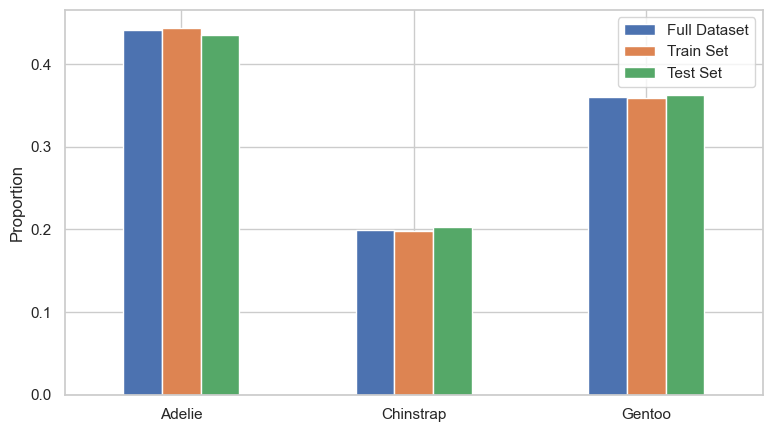

In [20]:
species_ratio.plot.bar(rot=0, figsize=(9, 5))

plt.xlabel("")
plt.ylabel("Proportion")
plt.show()

아래 그래프는 세 데이터셋의 분포를 상자그림으로 비교한다.
`strat_compare` 변수는 세 데이터셋을 구분하는 용도의 `dataset` 특성을
지정한 후에 하나의 데이터프레임으로 합친다.

세 상자그림의 위치와 폭이 비슷하면 층화 표본이 전체 데이터의 수치형 특성 분포도를
잘 유지한다고 볼 수 있다.

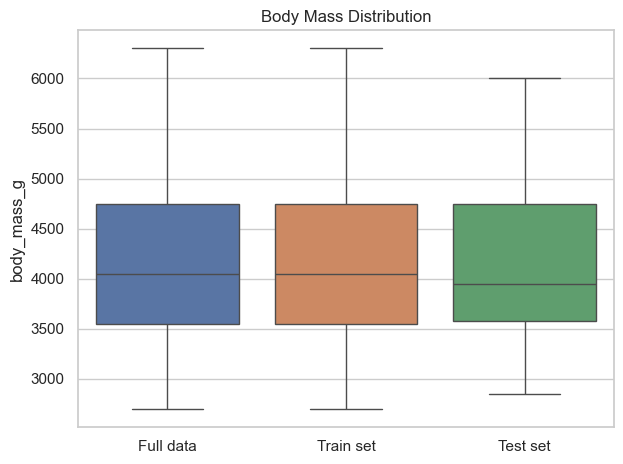

In [21]:
strat_compare = pd.concat(
    [
        penguins.assign(dataset="Full data"),
        penguins_train_strat.assign(dataset="Train set"),
        penguins_test_strat.assign(dataset="Test set"),
    ],
    ignore_index=True,
)

sns.boxplot(
    data=strat_compare,
    x="dataset",
    y="body_mass_g",
    hue="dataset",
    legend=False,
)
plt.title("Body Mass Distribution")
plt.xlabel("")
plt.ylabel("body_mass_g")
plt.tight_layout()
plt.show()


**`species` 특성 삭제**

`species` 특성은 층화 샘플링에만 사용되었으므로 더 이상 필요하지 않다.
따라서 훈련셋과 테스트셋에서 `species` 특성을 삭제하여,
회귀 모델 훈련과 평가에 사용할 데이터셋을 준비한다.

In [22]:
penguins_train = penguins_train_strat.drop(columns="species")
penguins_test = penguins_test_strat.drop(columns="species")

## 6단계: 탐색적 데이터 분석

머신러닝 모델 훈련을 본격적으로 시작하기에 앞서
아래 질문과 관련하여 탐색적 데이터 분석(EDA)을 진행한다.

> 신체 측정값이 몸무게 예측에 도움이 될까?

지금까지와 달리, 여기서는 훈련셋만을 대상으로 EDA를 진행한다.

:::{warning} 테스트셋 살펴보기

테스트셋을 훈련셋처럼 다양한 방식으로 살펴보는 일은 절대로 하면 안 된다.
테스트셋은 아직 관측하지 않은, 미래에 얻을 수 있는 데이터를 대신하는 자료이므로
테스트셋에 대한 어떤 정보도 없다고 가정해야 한다.
:::

**입력 특성과 타깃**

모델의 예측에 사용되는 값을 담은 특성을 **입력 특성**,
모델이 예측하려는 값을 담은 특성을 **타깃**이라 부른다.
아래 코드는 입력 특성으로 사용할 특성들의 리스트와 타깃을 지정한다.

In [23]:
input_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
target = "body_mass_g"

**산점도**

부리 길이, 부리 두께, 날개 길이 세 가지 값을 입력으로 사용하여
펭귄의 몸무게를 예측하는 선형 회귀 모델을 훈련할 예정이므로,
입력 특성과 몸무게 사이의 관계를 산점도로 살펴볼 필요가 있다.

아래 코드는 각 입력 특성과 타깃 사이의 산점도를 그린다.

- 날개 길이와 몸무게 사이에는 뚜렷한 양의 상관관계가 관찰된다.
- 부리 길이도 몸무게와 어느 정도 양의 관계를 보인다.
- 부리 두께는 종에 따른 집단 차이가 함께 나타나므로 단순한 선형 관계로 해석하기 어렵다.

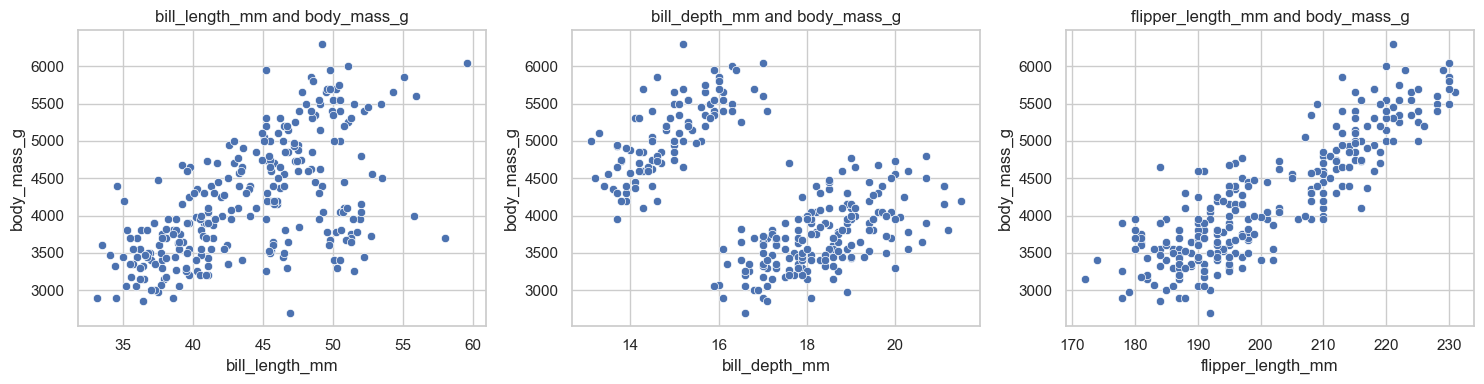

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for feature, ax in zip(input_features, axes):
    sns.scatterplot(
        data=penguins_train,
        x=feature,
        y=target,
        ax=ax,
        legend=(feature == input_features[-1]),
    )
    ax.set_title(f"{feature} and {target}")

plt.tight_layout()
plt.show()

**상관계수**

아래 코드는 산점도에서 확인한 특성 사이의 상관관계를 히트맵으로 시각화한다.

타깃인 몸무게와 각 입력 특성 사이의 상관계수를 절댓값 기준으로 비교하면,
날개 길이와 몸무게 사이의 상관계수가 약 0.87로 가장 높다.
즉, 날개 길이와 몸무게 사이에는 강한 양의 선형 상관관계가 있다.

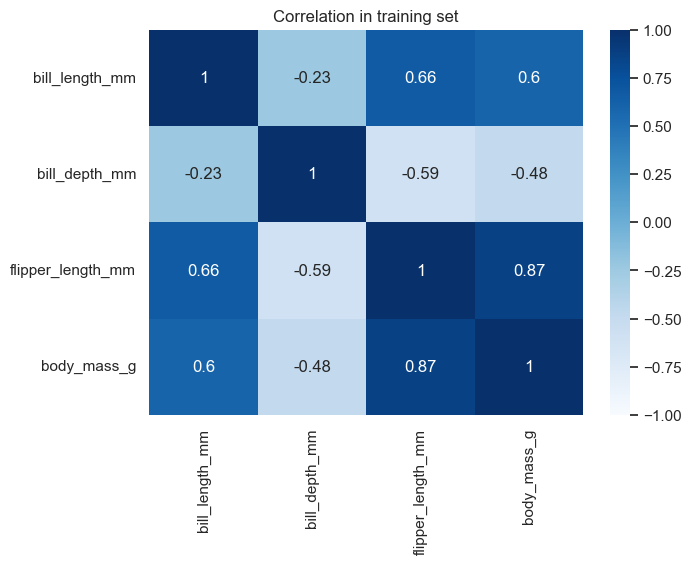

In [25]:
correlation_columns = input_features + [target]
corr = penguins_train[correlation_columns].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation in training set")
plt.show()

**입력 특성의 스케일**

상관계수를 통해 입력 특성과 타깃 사이의 관계를 확인했다.
이제 모델 훈련에 사용될 입력 특성들의 값의 범위를 살펴본다.

입력 특성들의 스케일이 서로 다르면 일부 머신러닝 모델은 특정 특성의 영향을 상대적으로 크게 반영할 수 있다.
따라서 전처리를 진행하기 전에 각 입력 특성의 평균, 표준편차, 최솟값, 최댓값 등을 확인한다.

In [26]:
penguins_train[input_features].describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm
count,273.000000,273.000000,273.000000
mean,44.071795,17.134799,200.948718
std,5.496146,2.008492,13.907954
min,33.100000,13.100000,172.000000
25%,39.500000,15.300000,190.000000
50%,44.900000,17.300000,197.000000
75%,48.700000,18.700000,213.000000
max,59.600000,21.500000,231.000000


세 입력 특성은 모두 mm 단위로 측정되었지만 값의 범위와 표준편차가 서로 다르다.
특히 날개 길이는 부리 길이와 부리 두께보다 값의 범위가 훨씬 크다.
따라서 입력 특성들이 모델 훈련 과정에서 균형 있게 반영되도록 표준화를 적용할 필요가 있다.

표준화 전처리를 진행하기 전에 입력 특성으로 구성된 입력 데이터셋과 타깃 특성만 사용하는 타깃셋을 지정한다.

In [27]:
X_train = penguins_train[input_features] # 입력 데이터셋
y_train = penguins_train[target]         # 타깃셋

## 7단계: 전처리

일부 머신러닝 모델은 입력 특성들의 스케일이 비슷할 때 더 안정적으로 학습된다.
앞서 확인했듯이 부리 길이, 부리 두께, 날개 길이는 값의 범위와 표준편차가 서로 다르다.
따라서 여기서는 세 입력 특성을 표준화한 뒤 머신러닝 모델 훈련에 활용한다.

[기술통계](#ch-descriptive-stats)에서 설명한 표준화는 각 입력 특성에서 평균을 빼고 표준편차로 나누어,
평균이 0이고 표준편차가 1이 되도록 변환하는 방법이다.
이를 통해 서로 다른 범위를 가진 특성들이 모델 학습 과정에서 균형 있게 반영될 수 있다.

**표준화 변환기**

사이킷런의 `StandardScaler`는 여러 특성을 동시에 표준화하는 기능을 제공하는 변환기 클래스다.
사용법은 다음과 같다.

1. `StandardScaler` 클래스의 인스턴스를 생성한다.
2. 표준화할 특성들로 구성된 데이터프레임 또는 넘파이 어레이를 인자로 전달하여 `fit_transform()` 메서드를 호출한다.
3. `fit_transform()` 메서드는 먼저 `fit()` 메서드로 특성별 평균과 표준편차를 계산한 뒤,
   그 값을 이용해 `transform()` 메서드로 표준화를 수행하고, 그 결과를 2차원 넘파이 어레이로 반환한다.

아래 코드에서 `X_train_scaled`는 입력 특성으로 사용할 부리 길이, 부리 두께, 날개 길이를 표준화한
2차원 넘파이 어레이를 가리킨다.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

아래 코드는 특성들의 이름을 추가하여 데이터프레임으로 지정한다.

In [29]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=input_features)

`X_train_scaled`의 모든 특성의 평균값은 0, 표준편차는 1이다.
아래 코드가 이를 확인해준다.

In [30]:
X_train.mean()

bill_length_mm        44.071795
bill_depth_mm         17.134799
flipper_length_mm    200.948718
dtype: float64

In [31]:
X_train.std()

bill_length_mm        5.496146
bill_depth_mm         2.008492
flipper_length_mm    13.907954
dtype: float64

:::{note} 타깃 특성 표준화

경우에 따라 타깃 특성을 변환하거나 스케일링할 수 있지만, 여기서는 입력 특성만 표준화하고 타깃 특성은 그대로 사용한다.
:::

## 8단계: 모델 훈련

훈련셋을 이용한 EDA에서 날개 길이를 포함한 신체 측정값이 몸무게와 관련되어 있음을 확인했다.
이제 세 가지 신체 측정값을 이용해 **몸무게를 예측하는 회귀 모델**을 훈련시킨다.
훈련을 마친 회귀 모델은 어떤 펭귄의 부리 길이, 부리 두께, 날개 길이 값이 주어졌을 때
그 펭귄의 몸무게 추정값을 계산한다.

모델 훈련 결과의 차이를 살펴보기 위해 두 종류의 지도 학습 모델을 각각 훈련한 뒤 결과를 비교한다.

- 선형 회귀 모델
- 확률적 경사하강법 모델

**지도 학습**

파머 펭귄 데이터셋의 신체 측정값을 이용한 회귀 모델 훈련 과정은 다음과 같다.

- 훈련셋에 포함된 각 펭귄의 부리와 날개 측정값을 입력으로 사용하여 해당 펭귄의 몸무게를 예측한다.
- 몸무게 예측값과 실제 몸무게 사이의 오차가 작아지도록, 신체 측정값과 몸무게 사이의 관계를 학습한다.

이처럼 지도 학습은 예측값과 실제값 사이의 오차를 줄이는 방향으로 모델을 훈련시키는 방식이다.

**입력 데이터셋과 타깃셋**

지도 학습 방식으로 머신러닝 모델을 훈련하려면
훈련셋을 입력 데이터셋과 타깃셋으로 나누어야 한다.
앞서 지정한 입력 특성과 타깃을 기준으로 다음과 같이 구분한다.

- **입력 특성**: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`
- **타깃 특성**: `body_mass_g`

훈련에 사용되는 입력 데이터셋은 총 273개의 샘플과 3개의 특성으로 구성된다.

In [32]:
X_train.shape

(273, 3)

### 선형 회귀 모델

준비된 입력 데이터셋과 타깃셋을 이용하여 
선형 회귀 모델을 훈련시키기 위해 먼저 훈련시킬 선형 회귀 모델을 지정한다.

**사이킷런의 `LinearRegression` 클래스**

아래 코드는 사이킷런에서 제공하는 `LinearRegression` 클래스를 사용하여
선형 회귀 모델을 정의한다.

In [33]:
from sklearn.linear_model import LinearRegression

linear_reg_model_scaled = LinearRegression()

**모델 훈련**

사이킷런 모델은 `fit()` 메서드를 사용하여 훈련한다.
`fit()` 메서드는 일반적으로 입력 데이터셋과 타깃셋을 인자로 받으며,
다음과 같은 형식으로 호출한다.

```python
모델명.fit(입력데이터셋, 타깃셋)
```

아래 코드는 표준화된 입력 데이터셋을 이용하여 선형 회귀 모델의 파라미터를 계산한다.

In [34]:
linear_reg_model_scaled.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


`fit()` 메서드는 입력 데이터셋 `X_train`에 포함된 펭귄들의 신체 측정값과
타깃셋 `y_train`에 저장된 실제 몸무게를 함께 사용하여 선형 회귀 모델의 파라미터를 계산한다.

선형 회귀 모델은 신체 측정값을 바탕으로 계산한 몸무게 예측값과 실제 몸무게 사이의 오차 제곱합이
가장 작아지도록 계수와 절편을 정한다.
여기서 계수와 절편은 모델이 예측값을 계산할 때 입력값과 함께 사용하는 내부 파라미터다.

`fit()` 메서드가 실행되고 나면
모델 객체 내부에는 새로운 입력 데이터에 대한 예측값을 계산하는 데 필요한 계수와 절편이 저장된다.

**모델 예측값**

훈련을 마친 모델은 새로운 입력 데이터에 대해 예측값을 계산할 수 있다.
사이킷런 모델에서는 `predict()` 메서드를 사용하여 예측을 수행한다.

`predict()` 메서드는 입력 데이터셋을 인자로 받아,
데이터셋에 포함된 각 샘플에 대한 예측값을 담은 1차원 어레이를 반환한다.

예를 들어 훈련셋의 입력 데이터셋 `X_train`에 대한 몸무게 예측값은 다음과 같이 계산할 수 있다.

In [35]:
y_train_pred_linear_scaled = linear_reg_model_scaled.predict(X_train_scaled)

**평균 제곱근 오차**

회귀 모델의 성능은 일반적으로 평균 제곱근 오차<font size='2'>Root Mean Squared Error, RMSE</font>로 평가된다.
RMSE는 모델의 예측값과 실제값 사이의 차이, 즉 오차를 제곱한 값들의 평균에 다시 제곱근을 취한 값이다.

$$
\mathrm{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 }
$$

위 식에서 $n$은 데이터 샘플의 개수,
$y_i$는 $i$번째 샘플의 실제값,
$\hat{y}_i$는 $i$번째 샘플에 대한 모델의 예측값을 의미한다.
따라서 $(y_i - \hat{y}_i)$는 $i$번째 샘플에서 발생한 예측 오차를 나타낸다.

RMSE 값이 작을수록 모델의 예측값이 실제값에 더 가깝다는 뜻이며,
따라서 모델의 성능이 더 좋다고 해석할 수 있다.

선형 회귀 모델의 훈련셋에 대한 RMSE는 396.52이다.
이는 훈련셋에서 몸무게 예측값이 실제 몸무게와 평균적으로 약 397g 정도 차이 난다는 뜻이다.

In [36]:
from sklearn.metrics import root_mean_squared_error

# 훈련셋 RMSE 계산
rmse_linear_scaled = root_mean_squared_error(y_train, y_train_pred_linear_scaled)
print(f"표준화된 훈련셋으로 학습한 선형회귀 모델의 훈련셋 RMSE: {rmse_linear_scaled:.2f}")

표준화된 훈련셋으로 학습한 선형회귀 모델의 훈련셋 RMSE: 396.52


반면에 아래 코드는 표준화하지 않은 입력 데이터셋으로 선형 회귀 모델을 훈련한 결과를 보여준다.
선형 회귀 모델에서는 입력 데이터셋을 표준화한 경우와 그렇지 않은 경우의 예측 성능에 차이가 없다.
다만 표준화 여부에 따라 모델의 계수 값은 달라진다.
그러나 선형 회귀 모델의 예측값과 RMSE는 동일하게 유지된다.

In [37]:
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)
y_train_pred_linear = linear_reg_model.predict(X_train)

rmse_linear = root_mean_squared_error(y_train, y_train_pred_linear)
print(f"표준화되지 않은 훈련셋으로 학습한 선형회귀 모델의 훈련셋 RMSE: {rmse_linear:.2f}")

표준화되지 않은 훈련셋으로 학습한 선형회귀 모델의 훈련셋 RMSE: 396.52


### 확률적 경사하강법 모델

선형 회귀 모델의 경우 표준화 전처리의 효과가 전혀 없었지만 훈련 모델에 따라 결과가 크게 달라질 수 있다.
예를 들어 아래 두 코드는 확률적 경사하강법 모델을 표준화된 훈련셋을 사용한 경우와 그렇지 않은 경우가 극단적으로 달라질 수 있음을 잘 보여준다.

확률적 경사하강법 모델은 표준화된 입력 훈련셋을 사용했을 때 선형 회귀 모델과 거의 비슷한 성능을 보이지만, 성능은 아주 조금 낮다.

In [38]:
from sklearn.linear_model import SGDRegressor

sgd_reg_model_scaled = SGDRegressor(random_state=42)
sgd_reg_model_scaled.fit(X_train_scaled, y_train)

y_train_pred_sgd_scaled = sgd_reg_model_scaled.predict(X_train_scaled)

rmse_sgd_scaled = root_mean_squared_error(y_train, y_train_pred_sgd_scaled)
print(f"표준화된 훈련셋으로 학습한 SGD 모델의 훈련셋 RMSE: {rmse_sgd_scaled:.2f}")

표준화된 훈련셋으로 학습한 SGD 모델의 훈련셋 RMSE: 396.55


표준화되지 않은 입력 훈련셋으로 훈련한 확률적 경사하강법 모델의 훈련셋 RMSE는 터무니없이 크다.

In [39]:
from sklearn.linear_model import SGDRegressor

sgd_reg_model = SGDRegressor(random_state=42)
sgd_reg_model.fit(X_train, y_train)

y_train_pred_sgd = sgd_reg_model.predict(X_train)

rmse_sgd = root_mean_squared_error(y_train, y_train_pred_sgd)
print(f"표준화되지 않은 훈련셋으로 학습한 SGD 모델의 훈련셋 RMSE: {rmse_sgd:.2f}")

표준화되지 않은 훈련셋으로 학습한 SGD 모델의 훈련셋 RMSE: 24545578368031.07


이는 입력 특성의 스케일 차이로 인해 모델이 제대로 수렴하지 못했기 때문으로 보인다.
이런 경우에는 학습률을 조정하면 성능이 좋아질 수 있다.

학습률은 경사하강법에서 한 번의 업데이트마다 모델의 파라미터를 얼마나 크게 조정할지를 정하는 값이다.
학습률이 너무 크면 파라미터가 적절한 값으로 수렴하지 못하고 크게 흔들릴 수 있으며,
학습률이 너무 작으면 수렴 속도가 지나치게 느려질 수 있다.

아래 코드는 학습률을 기본값인 0.01 대신 0.0001로 지정하면
훈련셋에 대한 RMSE가 약 476으로 계산됨을 보여준다.
이는 표준화된 훈련셋을 사용한 경우보다는 여전히 나쁘지만,
앞선 결과에 비하면 정상적인 범위의 예측 성능이다.

In [40]:
from sklearn.linear_model import SGDRegressor

sgd_reg_model = SGDRegressor(eta0=0.0001, random_state=42)
sgd_reg_model.fit(X_train, y_train)

y_train_pred_sgd = sgd_reg_model.predict(X_train)

rmse_sgd = root_mean_squared_error(y_train, y_train_pred_sgd)
print(f"표준화되지 않은 훈련셋으로 학습한 SGD 모델의 훈련셋 RMSE: {rmse_sgd:.2f}")

표준화되지 않은 훈련셋으로 학습한 SGD 모델의 훈련셋 RMSE: 476.43


입력 특성의 스케일을 표준화 기법으로 통일시키지 않은 경우 훈련 성능이 나쁜 이유는
확률적 경사하강법이 입력값의 크기에 따라 파라미터 업데이트 폭이 크게 달라지는 방식으로 작동하기 때문이다.
따라서 특성들의 스케일 차이가 크면 학습 과정이 불안정해지고 모델이 제대로 수렴하지 못할 수 있다.

## 9단계: 모델 평가

훈련된 모델의 성능은 훈련 과정에서 사용하지 않은 테스트셋을 이용하여 평가한다.
훈련에 사용된 데이터는 모델이 상대적으로 잘 예측할 가능성이 높기 때문이다.

파머 데이터셋을 학습한 선형 회귀 모델과 확률적 경사하강법 모델의 테스트셋 RMSE를 계산하기 위해,
훈련셋에서와 마찬가지로 먼저 테스트셋을 입력 데이터셋과 타깃셋으로 구분한다.
그다음 테스트셋의 입력 데이터셋도 표준화한다.

다만 테스트셋을 표준화할 때 입력 특성별 평균과 표준편차는
훈련셋을 표준화할 때 계산한 값을 사용한다.
테스트셋은 아직 관측하지 않은 새로운 데이터를 대신하는 자료이므로,
모델 평가 전에 테스트셋의 통계 정보를 이용해서는 안 된다.

**`StandardScaler` 변환기 활용**

훈련셋을 표준화할 때 계산된 입력 특성별 평균과 표준편차는 `scaler` 변환기에 저장되어 있다.
따라서 `transform()` 메서드를 이용하여 테스트셋을 변환하면,
훈련셋에서 계산된 평균과 표준편차를 기준으로 테스트셋이 표준화된다.

참고로 훈련셋의 입력 특성값을 변환할 때는 `fit_transform()` 메서드를 사용하여
특성별 평균과 표준편차를 계산하고 표준화를 수행했다.
하지만 테스트셋에서는 새로운 평균과 표준편차를 계산하면 안 되므로,
저장된 값을 이용하는 `transform()` 메서드만 호출한다.

In [41]:
X_test = penguins_test[input_features]             # 테스트셋 입력 특성값
X_test_scaled_array = scaler.transform(X_test)     # 테스트셋 입력 특성값 표준화

X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=input_features) # 표준화된 테스트셋 입력 특성값을 데이터프레임으로 변환
y_test = penguins_test[target]                                            # 테스트셋 타깃값

테스트셋은 총 69개의 샘플로 구성된다.

In [42]:
len(y_test)

69

테스트셋에 대한 선형 회귀 모델의 테스트셋에 대한 RMSE는 약 370 정도로 훈련셋의 경우보다 다소 낮게 계산된다.

In [43]:
from sklearn.metrics import root_mean_squared_error

# 테스트셋에 대한 예측값 계산
y_test_pred_linear = linear_reg_model_scaled.predict(X_test_scaled)

# RMSE 계산
rmse_linear_test = root_mean_squared_error(y_test, y_test_pred_linear)
print(f"RMSE: {rmse_linear_test:.2f}")

RMSE: 369.41


확률적 경사하강법 모델의 테스트셋에 대한 RMSE도 거의 동일하다.

In [44]:
from sklearn.linear_model import SGDRegressor

y_test_pred_sgd = sgd_reg_model_scaled.predict(X_test_scaled)
rmse_sgd_test = root_mean_squared_error(y_test, y_test_pred_sgd)

print(f"SGDRegressor RMSE: {rmse_sgd_test:.2f}")

SGDRegressor RMSE: 369.50


:::{note} 훈련셋 대 테스트셋

일반적으로 훈련셋에 대한 성능이 테스트셋보다 좋을 것으로 기대하지만,
데이터셋의 크기가 작고 훈련셋과 테스트셋의 샘플 구성이 달라지면
테스트셋의 예측 오차가 우연히 더 작게 나타날 수 있다.

특히 파머 펭귄 데이터셋처럼 샘플이 적은 경우에는 테스트셋에 상대적으로 예측하기 쉬운 샘플이 포함되었을 가능성이 있다.
따라서 테스트셋 RMSE가 훈련셋 RMSE보다 조금 낮게 나온다고 해서 이상한 결과는 아니다.
:::

**예측값 시각화**

테스트셋에 포함된 69마리 펭귄에 대한 선형 회귀 모델의 예측 몸무게와 실제 몸무게를 이용하여 산점도를 그리면 다음과 같다.
빨간 점선은 실제값과 예측값이 완전히 같은 경우를 나타내며,
점들이 이 선에 가까울수록 예측이 잘 된 것이다.

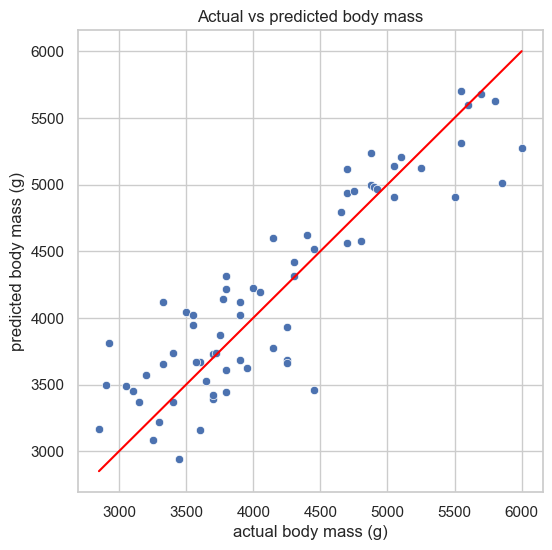

In [45]:
# 실제값과 예측값으로 구성된 데이터프레임 
test_results = pd.DataFrame({"actual": y_test,
                             "predicted": y_test_pred_linear})

# 실제값과 예측값의 산점도
plt.figure(figsize=(6, 6))
sns.scatterplot(data=test_results, x="actual", y="predicted")

# 45도 선 추가
min_value = min(test_results["actual"].min(), test_results["predicted"].min())
max_value = max(test_results["actual"].max(), test_results["predicted"].max())
plt.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="-")

plt.title("Actual vs predicted body mass")
plt.xlabel("actual body mass (g)")
plt.ylabel("predicted body mass (g)")
plt.show()

## 연습문제

**문제 1**

`bill_length_mm`, `bill_depth_mm`만 사용하여 몸무게를 예측하는 선형 회귀 모델을 훈련시켜 보아라. 세 특성을 모두 사용했을 때와 성능이 어떻게 달라지는가?

답:

`bill_length_mm`와 `bill_depth_mm` 두 특성만 사용하여 선형 회귀 모델을 새로 훈련한 다음,
앞에서 세 특성을 모두 사용한 모델의 RMSE와 비교한다.

In [46]:
# 부리 특성
bill_features = ["bill_length_mm", "bill_depth_mm"]

# 부리 특성으로 선형회귀 모델 학습
bill_reg_model = LinearRegression()
bill_reg_model.fit(X_train_scaled[bill_features], y_train)

# 부리 특성으로 테스트셋에 대한 예측값 계산
y_test_pred_bill = bill_reg_model.predict(X_test_scaled[bill_features])
rmse_linear_bill = root_mean_squared_error(y_test, y_test_pred_bill)

# RMSE 비교
print(f"세 특성 사용 RMSE: {rmse_linear_test:.2f}")
print(f"부리 특성만 사용 RMSE: {rmse_linear_bill:.2f}")

세 특성 사용 RMSE: 369.41
부리 특성만 사용 RMSE: 605.81


부리 길이와 부리 두께만 사용하면 날개 길이 정보를 사용하지 못하므로,
세 특성을 모두 사용한 모델보다 RMSE가 커진다.
실행 결과 부리 특성만 사용한 모델의 RMSE는 약 606으로,
세 특성을 모두 사용한 모델의 RMSE인 약 369보다 크다.
즉, 몸무게 예측 성능이 낮아진다고 해석할 수 있다.

**문제 2**

`flipper_length_mm` 하나만 사용하여 몸무게를 예측하는 선형 회귀 모델을 훈련시켜 보아라. 
날개 길이와 몸무게 사이의 높은 선형 상관관계가 모델의 회귀 성능에도 반영되는지 확인하라.

답:

`flipper_length_mm` 하나만 입력 특성으로 사용하여 선형 회귀 모델을 훈련한다.

In [47]:
# 날개 길이 특성
flipper_features = ["flipper_length_mm"]

# 날개 길이 특성으로 선형회귀 모델 학습
flipper_reg_model = LinearRegression()
flipper_reg_model.fit(X_train_scaled[flipper_features], y_train)

# 날개 길이 특성으로 테스트셋에 대한 예측값 계산
y_test_pred_flipper = flipper_reg_model.predict(X_test_scaled[flipper_features])
rmse_linear_flipper = root_mean_squared_error(y_test, y_test_pred_flipper)

# RMSE 비교
print(f"세 특성 사용 RMSE: {rmse_linear_test:.2f}")
print(f"날개 길이만 사용 RMSE: {rmse_linear_flipper:.2f}")

세 특성 사용 RMSE: 369.41
날개 길이만 사용 RMSE: 373.40


실행 결과 날개 길이만 사용한 모델의 RMSE는 약 373으로,
세 특성을 모두 사용한 모델의 RMSE인 약 369와 큰 차이가 나지 않는다.
날개 길이는 몸무게와 강한 양의 상관관계를 보였는데,
이 점이 모델 훈련 결과에도 반영되었음을 확인할 수 있다.

다만 다른 신체 측정값을 함께 사용하는 모델보다 성능이 더 좋지는 않다.

**문제 3**

훈련셋과 테스트셋을 나눌 때 `stratify` 옵션을 제거해서 단순 무작위 샘플링으로 진행한 다음에
선형 회귀 모델을 훈련시켜 보아라. 모델의 성능 평가 결과가 달라지는지 확인해 보아라.

답:

`stratify` 옵션을 사용하지 않으면 단순 무작위 샘플링으로 훈련셋과 테스트셋이 나뉜다.
아래 코드는 동일한 입력 특성과 선형 회귀 모델을 사용하되, 데이터 분할 방식만 바꾸어 RMSE를 비교한다.

In [48]:
# 무작위 샘플링으로 훈련셋과 테스트셋 분할
penguins_train_random, penguins_test_random = train_test_split(
    penguins,
    test_size=0.2,
    random_state=42,
)

# 종(species) 특성 제거
penguins_train_random = penguins_train_random.drop(columns="species")
penguins_test_random = penguins_test_random.drop(columns="species")

# 무작위 샘플링으로 분할된 데이터셋에서 입력 특성과 타깃 특성 지정
X_train_random = penguins_train_random[input_features]
y_train_random = penguins_train_random[target]
X_test_random = penguins_test_random[input_features]
y_test_random = penguins_test_random[target]

# 무작위 샘플링으로 분할된 데이터셋으로 선형회귀 모델 학습
random_split_reg_model = LinearRegression()
random_split_reg_model.fit(X_train_random, y_train_random)

# 무작위 샘플링으로 분할된 데이터셋으로 학습한 모델로 테스트셋에 대한 예측값 계산
y_test_pred_random = random_split_reg_model.predict(X_test_random)
rmse_linear_random = root_mean_squared_error(y_test_random, y_test_pred_random)

# RMSE 비교
print(f"층화 샘플링 RMSE: {rmse_linear_test:.2f}")
print(f"무작위 샘플링 RMSE: {rmse_linear_random:.2f}")

층화 샘플링 RMSE: 369.41
무작위 샘플링 RMSE: 375.64


`stratify` 옵션을 제거하면 테스트셋에 포함되는 종별 비율이 달라질 수 있으므로 RMSE도 달라질 수 있다.
실행 결과 무작위 샘플링을 사용했을 때의 RMSE는 약 376으로,
층화 샘플링을 사용했을 때의 RMSE인 약 369와 약간 높다.

파머 펭귄 데이터셋처럼 데이터셋의 크기가 크지 않고 종별 몸무게 차이가 있는 경우에는,
층화 샘플링을 사용하여 종별 비율을 유지하는 편이 평가 결과를 더 안정적으로 해석하는 데 도움이 된다.

**문제 4**

사이킷런의 `RandomForestRegressor`를 사용하여 모델을 훈련한 뒤,
선형 회귀 모델과 RMSE를 비교하고 어떤 모델이 더 나은지 설명해 보아라.

답:

`RandomForestRegressor`는 여러 개의 결정 트리를 함께 사용하는 앙상블 회귀 모델이다.
아래 코드는 동일한 훈련셋과 테스트셋을 사용하여 랜덤 포레스트 회귀 모델을 훈련한 뒤,
선형 회귀 모델의 RMSE와 비교한다.

In [49]:
from sklearn.ensemble import RandomForestRegressor

# 무작위 샘플링으로 분할된 데이터셋으로 랜덤포레스트 회귀 모델 학습
forest_reg_model = RandomForestRegressor(random_state=42)
forest_reg_model.fit(X_train, y_train)

y_test_pred_forest = forest_reg_model.predict(X_test)
rmse_forest = root_mean_squared_error(y_test, y_test_pred_forest)

print(f"LinearRegression RMSE: {rmse_linear_test:.2f}")
print(f"RandomForestRegressor RMSE: {rmse_forest:.2f}")

LinearRegression RMSE: 369.41
RandomForestRegressor RMSE: 294.62


RMSE가 더 작은 모델이 테스트셋의 몸무게를 더 잘 예측한 모델이다.
실행 결과 `RandomForestRegressor`의 RMSE는 약 295로,
`LinearRegression`의 RMSE인 약 369보다 작다.
따라서 이 테스트셋에서는 랜덤 포레스트 회귀 모델이 선형 회귀 모델보다 몸무게를 더 잘 예측했다고 해석할 수 있다.

아래 코드는 랜덤 포레스트 모델을 표준화된 입력 데이터셋으로 훈련한 결과를 보여준다.
실행 결과는 표준화하지 않은 입력 데이터셋을 사용했을 때와 거의 동일하다.
이는 랜덤 포레스트가 특성의 크기 자체가 아니라,
특성값을 기준으로 데이터를 나누는 방식으로 작동하는 트리 기반 모델이기 때문이다.

In [50]:
from sklearn.ensemble import RandomForestRegressor

# 무작위 샘플링으로 분할된 데이터셋으로 랜덤포레스트 회귀 모델 학습
forest_reg_model_scaled = RandomForestRegressor(random_state=42)
forest_reg_model_scaled.fit(X_train_scaled, y_train)

y_test_pred_forest = forest_reg_model_scaled.predict(X_test_scaled  )
rmse_forest_scaled = root_mean_squared_error(y_test, y_test_pred_forest)

print(f"랜덤 포레스트 RMSE: {rmse_forest:.2f}")
print(f"표준화된 훈련셋 사용 랜덤 포레스트 RMSE: {rmse_forest_scaled:.2f}")

랜덤 포레스트 RMSE: 294.62
표준화된 훈련셋 사용 랜덤 포레스트 RMSE: 296.64
